# Model Validation & Credit Risk Application

**Module objectives**

By the end of this notebook, students will be able to:

1. Frame a credit-risk problem as a binary classification task and build a baseline **Logistic Regression** model for loan default prediction.
2. Recognise three biases that quietly damage model performance in financial / credit data:
   - **Survivorship bias** — only modelling the borrowers who made it into the dataset.
   - **Look-ahead bias** — leaking information from the future into the training set.
   - **Overfitting** — a model that memorises the training set instead of learning the signal.
3. Evaluate models using metrics that are **appropriate for imbalanced data** — precision, recall, F1, ROC-AUC, and especially the **Precision-Recall curve**.
4. Tune the classification threshold based on a **business-cost** view rather than blindly using 0.5.

**Dataset.** `datasets/Loan_default.csv` — ~255,000 loans, 17 features, target `Default` (0/1). The default rate is ~11.6%, so the data is imbalanced.

We **drop `LoanID`** since it is just a row identifier and carries no predictive information.

*Author: Manaranjan Pradhan*


---

## 1. Setup

A standard scikit-learn stack plus `statsmodels` for an interpretable logistic regression summary.


In [1]:
# Install if not available (uncomment the line below the first time)
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
import statsmodels.api as sm

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
RANDOM_STATE = 42


---

## 2. Load and inspect the data

We read the file, drop `LoanID`, and take a first look.


In [2]:
DATA_PATH = "datasets/Loan_default.csv"

loans = pd.read_csv(DATA_PATH)
loans = loans.drop(columns=["LoanID"])

print("Shape:", loans.shape)
loans.head()


Shape: (255347, 13)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,DTIRatio,MaritalStatus,HasMortgage,HasDependents,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.2300,0.4400,Divorced,Yes,Yes,Yes,0
1,69,50432,124440,458,15,1,4.8100,0.6800,Married,No,No,Yes,0
2,46,84208,129188,451,26,3,21.1700,0.3100,Divorced,Yes,Yes,No,1
3,32,31713,44799,743,0,3,7.0700,0.2300,Married,No,No,No,0
4,60,20437,9139,633,8,4,6.5100,0.7300,Divorced,No,Yes,No,0


In [3]:
loans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   DTIRatio        255347 non-null  float64
 8   MaritalStatus   255347 non-null  object 
 9   HasMortgage     255347 non-null  object 
 10  HasDependents   255347 non-null  object 
 11  HasCoSigner     255347 non-null  object 
 12  Default         255347 non-null  int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 25.3+ MB


In [4]:
loans.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,255347.0000,NaN,NaN,NaN,43.4983,14.9903,18.0000,31.0000,43.0000,56.0000,69.0000
Income,255347.0000,NaN,NaN,NaN,82499.3046,38963.0137,15000.0000,48825.5000,82466.0000,116219.0000,149999.0000
LoanAmount,255347.0000,NaN,NaN,NaN,127578.8655,70840.7061,5000.0000,66156.0000,127556.0000,188985.0000,249999.0000
CreditScore,255347.0000,NaN,NaN,NaN,574.2643,158.9039,300.0000,437.0000,574.0000,712.0000,849.0000
MonthsEmployed,255347.0000,NaN,NaN,NaN,59.5420,34.6434,0.0000,30.0000,60.0000,90.0000,119.0000
NumCreditLines,255347.0000,NaN,NaN,NaN,2.5010,1.1170,1.0000,2.0000,2.0000,3.0000,4.0000
InterestRate,255347.0000,NaN,NaN,NaN,13.4928,6.6364,2.0000,7.7700,13.4600,19.2500,25.0000
DTIRatio,255347.0000,NaN,NaN,NaN,0.5002,0.2309,0.1000,0.3000,0.5000,0.7000,0.9000
MaritalStatus,255347,3,Married,85302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasMortgage,255347,2,Yes,127677,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2a. How imbalanced is the target?

The default rate is the **base rate** — the accuracy you would get by always predicting "no default".
Any model we build has to beat this *meaningfully*, not just slightly.


Default rate: 11.6128%
Non-default rate (naive accuracy): 88.3872%


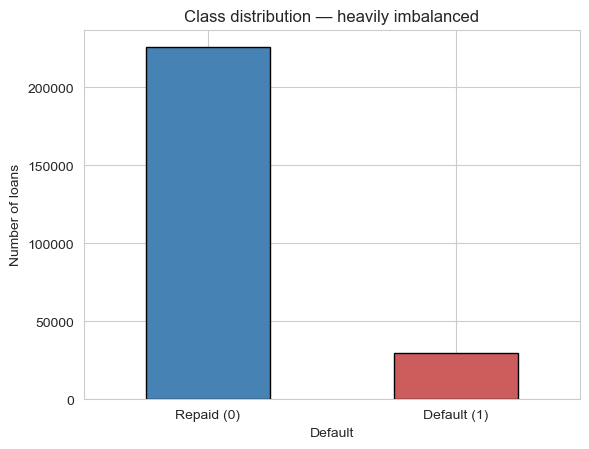

In [5]:
default_rate = loans["Default"].mean()
print(f"Default rate: {default_rate:.4%}")
print(f"Non-default rate (naive accuracy): {1 - default_rate:.4%}")

ax = loans["Default"].value_counts().plot(
    kind="bar", color=["steelblue", "indianred"], edgecolor="black"
)
ax.set_xticklabels(["Repaid (0)", "Default (1)"], rotation=0)
ax.set_ylabel("Number of loans")
ax.set_title("Class distribution — heavily imbalanced")
plt.show()


**Teaching point.** A model that predicts "no default" for every loan would be ~88% accurate.
That is why **accuracy alone is a misleading metric** in credit risk.
We will come back to this when we discuss precision and recall.


---

## 2b. Exploratory Data Analysis — key features vs Default

Before modelling, it is worth looking at how a few candidate features relate to the target.
We focus on four features that are commonly load-bearing in credit-risk models:

- **Age** — numeric, continuous.
- **DTIRatio** (debt-to-income) — numeric, continuous.
- **MaritalStatus** — categorical.
- **HasCoSigner** — categorical (Yes / No).

For numeric features we compare the **distribution by default class** (KDE) and a **boxplot**.
For categorical features we plot the **default rate per category** with a horizontal reference line at the overall base rate (~11.6%) — bars above the line are riskier-than-average segments.

> **Note.** EDA is done on the full dataset for exploration. We are *not* engineering features from these summaries — once we move to modelling (Section 4 onwards) all preprocessing is fit only on the training split, to avoid look-ahead bias.

### Age vs Default

Younger borrowers usually have shorter credit histories and tighter cash flows, so we expect a mild negative association between age and default.

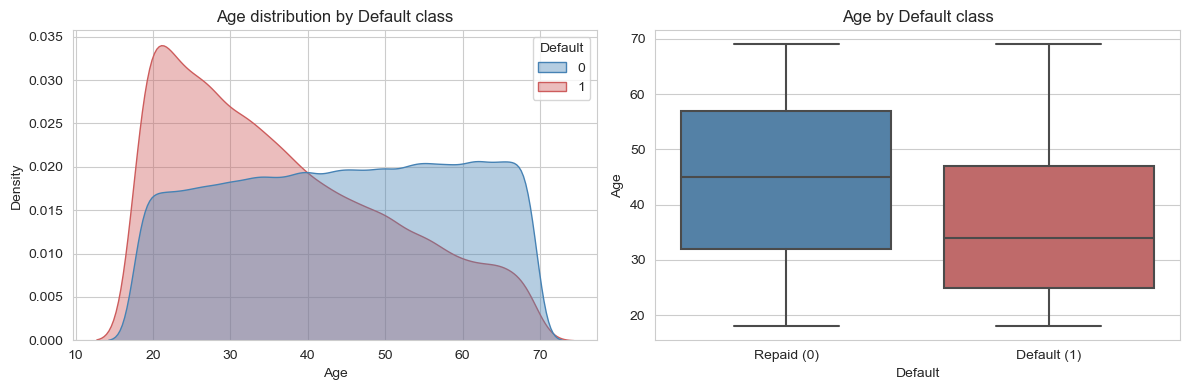

Mean Age by Default class:
           mean  median     std
Default                        
0       44.4100 45.0000 14.8900
1       36.5600 34.0000 13.9000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE — distribution of Age split by Default
sns.kdeplot(
    data=loans, x="Age", hue="Default",
    common_norm=False, fill=True, alpha=0.4,
    palette={0: "steelblue", 1: "indianred"}, ax=axes[0],
)
axes[0].set_title("Age distribution by Default class")
axes[0].set_xlabel("Age")

# Boxplot — Age by Default
sns.boxplot(
    data=loans, x="Default", y="Age",
    palette={0: "steelblue", 1: "indianred"}, ax=axes[1],
)
axes[1].set_xticklabels(["Repaid (0)", "Default (1)"])
axes[1].set_title("Age by Default class")

plt.tight_layout()
plt.show()

print("Mean Age by Default class:")
print(loans.groupby("Default")["Age"].agg(["mean", "median", "std"]).round(2))

### DTIRatio vs Default

Debt-to-income ratio is a direct measure of repayment burden. We expect defaulters to have **higher** DTI on average.

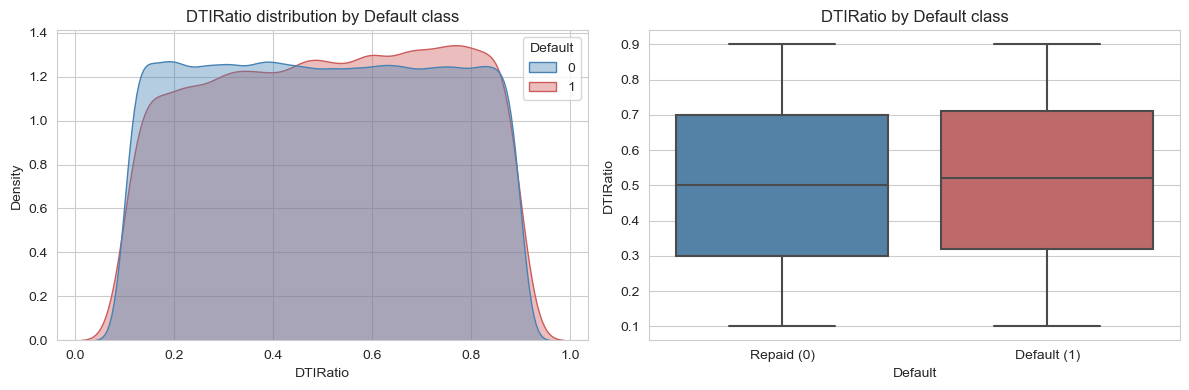

DTIRatio by Default class:
          mean  median    std
Default                      
0       0.4986  0.5000 0.2311
1       0.5125  0.5200 0.2292


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(
    data=loans, x="DTIRatio", hue="Default",
    common_norm=False, fill=True, alpha=0.4,
    palette={0: "steelblue", 1: "indianred"}, ax=axes[0],
)
axes[0].set_title("DTIRatio distribution by Default class")
axes[0].set_xlabel("DTIRatio")

sns.boxplot(
    data=loans, x="Default", y="DTIRatio",
    palette={0: "steelblue", 1: "indianred"}, ax=axes[1],
)
axes[1].set_xticklabels(["Repaid (0)", "Default (1)"])
axes[1].set_title("DTIRatio by Default class")

plt.tight_layout()
plt.show()

print("DTIRatio by Default class:")
print(loans.groupby("Default")["DTIRatio"].agg(["mean", "median", "std"]).round(4))

### MaritalStatus vs Default

For a categorical feature, the most informative view is the **default rate within each category**, compared to the overall base rate.

               default_rate      n
MaritalStatus                     
Divorced             0.1253  85033
Single               0.1191  85012
Married              0.1040  85302


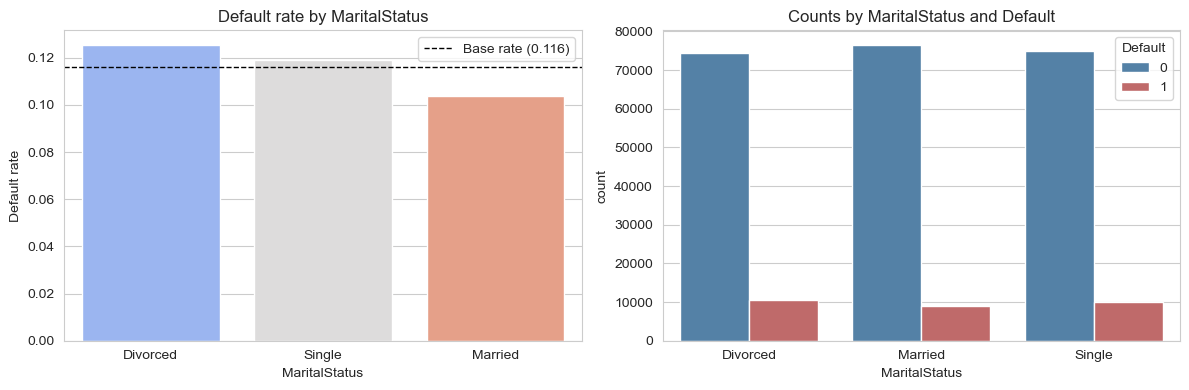

In [8]:
base_rate = loans["Default"].mean()

ms = (
    loans.groupby("MaritalStatus")["Default"]
         .agg(["mean", "count"])
         .rename(columns={"mean": "default_rate", "count": "n"})
         .sort_values("default_rate", ascending=False)
)
print(ms.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Default rate by MaritalStatus
sns.barplot(
    x=ms.index, y=ms["default_rate"],
    palette="coolwarm", ax=axes[0],
)
axes[0].axhline(base_rate, color="black", linestyle="--", lw=1,
                label=f"Base rate ({base_rate:.3f})")
axes[0].set_ylabel("Default rate")
axes[0].set_title("Default rate by MaritalStatus")
axes[0].legend()

# Counts by MaritalStatus and Default — to check that no segment is just tiny
sns.countplot(
    data=loans, x="MaritalStatus", hue="Default",
    palette={0: "steelblue", 1: "indianred"}, ax=axes[1],
)
axes[1].set_title("Counts by MaritalStatus and Default")

plt.tight_layout()
plt.show()

### HasCoSigner vs Default

A co-signer effectively adds a second person liable for the loan, which we expect to **lower** the default rate.

             default_rate       n
HasCoSigner                      
No                 0.1287  127646
Yes                0.1036  127701


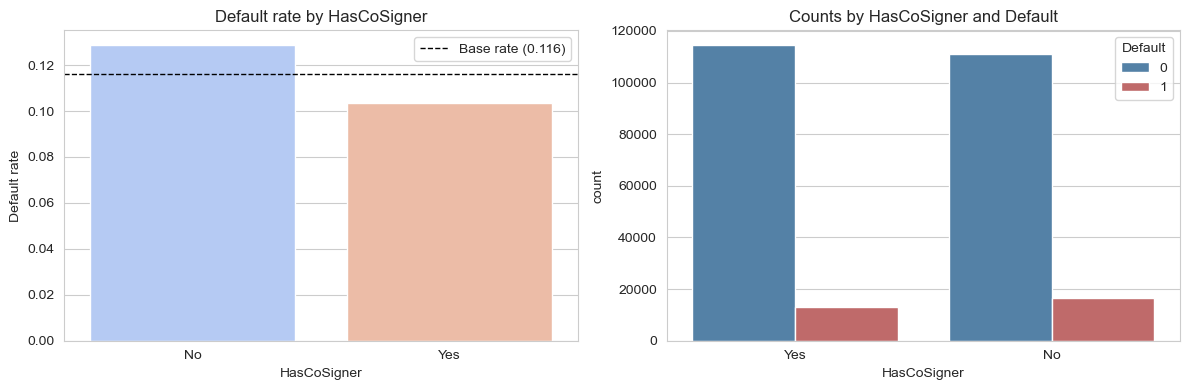

In [9]:
cs = (
    loans.groupby("HasCoSigner")["Default"]
         .agg(["mean", "count"])
         .rename(columns={"mean": "default_rate", "count": "n"})
         .sort_values("default_rate", ascending=False)
)
print(cs.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=cs.index, y=cs["default_rate"],
    palette="coolwarm", ax=axes[0],
)
axes[0].axhline(base_rate, color="black", linestyle="--", lw=1,
                label=f"Base rate ({base_rate:.3f})")
axes[0].set_ylabel("Default rate")
axes[0].set_title("Default rate by HasCoSigner")
axes[0].legend()

sns.countplot(
    data=loans, x="HasCoSigner", hue="Default",
    palette={0: "steelblue", 1: "indianred"}, ax=axes[1],
)
axes[1].set_title("Counts by HasCoSigner and Default")

plt.tight_layout()
plt.show()

**What to take away.**

- The signal in any single feature is **modest** — no variable cleanly separates defaulters from repayers on its own. That is normal in credit risk and is exactly why we lean on a multivariate model (logistic regression) to combine many weak signals.
- The categorical default rates above sit relatively close to the base rate, which is another reminder that **AUC will probably be modest** and that we should not expect a dramatic confusion-matrix at the default 0.5 cutoff.
- We should still see these features come through with **statistically significant coefficients** in the `statsmodels` summary in Section 7.

---

## 3. Three biases that damage credit-risk models

Before touching scikit-learn, we pause to discuss three biases that are easy to introduce and hard to detect once they are baked into the model.

### 3a. Survivorship bias

**What it is.** The dataset only contains loans that made it into the system — borrowers who applied, were approved, and whose outcome (paid or defaulted) was recorded.
It does **not** contain:

- Applicants who were rejected.
- Loans that are still in progress and have no resolved outcome yet.
- Borrowers who never applied because they self-selected out.

**Why it matters.** A model trained only on the "survivors" learns the patterns of *approved* borrowers, not of *all potential borrowers*. If we then deploy that model to score new applicants — including profiles the bank would have rejected before — its predictions are unreliable on the very segment we most need to evaluate.

**How to mitigate.**

- Document the population the data came from and **be honest about who is missing**.
- Where possible, include data on rejected applications (some banks store these for exactly this reason).
- If the model is to be used on a different population, calibrate predictions on a representative sample before deploying.

### 3b. Look-ahead bias

**What it is.** Using a feature whose value would not have been known *at the time of the loan decision*. In credit risk the most common forms are:

- Including post-loan information (e.g. whether the borrower took a top-up loan after the original decision).
- Computing aggregate statistics (mean income, std of credit score, etc.) on the **full dataset** and then using them at training time. The training rows then "know" something about the test rows.
- Using a target-derived feature by accident (e.g. an updated credit score that the bureau revised *after* the default).

**Why it matters.** The model will look brilliant in backtesting and fall apart in production, because in production those future values genuinely do not exist yet.

**How to mitigate.**

- Split first, **transform later**. Fit scalers, encoders, imputers on the training set only, then apply them to the test set.
- Audit each feature: at the time of the loan decision, was this value already known?

### 3c. Overfitting

**What it is.** A model that fits the training set very well but generalises poorly to new data. With many features and a flexible model, you can drive training error close to zero and still have a useless model.

**Why it matters.** In credit risk, overfitting often hides behind a few extreme cases that the model has memorised. New applicants do not match those cases, and the model's predictions are off.

**How to mitigate.**

- Always evaluate on a **held-out test set** that the model has never seen.
- Use **cross-validation** to estimate how stable performance is.
- Prefer simpler models (logistic regression with regularisation) as a baseline before trying anything complex.
- Compare **train vs test** scores — a large gap is a warning sign.

We will demonstrate look-ahead avoidance and overfitting checks explicitly in code further down.


---

## 4. Train / test split (with stratification)

The very first thing we do is split the data — **before** any encoding, scaling, or feature engineering. This is the single most effective way to avoid the look-ahead trap described above.

We use `stratify=y` so that the default rate is preserved in both train and test. With 11.6% defaults, a random split could otherwise leave one of the splits with a noticeably different base rate.


In [10]:
y = loans["Default"]
X = loans.drop(columns=["Default"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}, default rate = {y_train.mean():.4%}")
print(f"Test : {X_test.shape}, default rate = {y_test.mean():.4%}")


Train: (204277, 12), default rate = 11.6127%
Test : (51070, 12), default rate = 11.6135%


---

## 5. Preprocessing

Logistic regression needs:

- **Numeric features** — kept as-is, but **scaled**. Scaling helps the optimiser converge and makes regularisation behave consistently across features.
- **Categorical features** — one-hot encoded so each category becomes its own indicator column.

We wrap both steps in a `ColumnTransformer` and put the whole thing inside a `Pipeline`. This is the right pattern for avoiding look-ahead bias: the scaler's mean and std are learned **only on `X_train`** when we call `pipeline.fit(X_train, y_train)`.


In [13]:
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate",
    "DTIRatio",
]
categorical_features = [
    "MaritalStatus",
    "HasMortgage", "HasDependents", "HasCoSigner",
]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ]
)


---

## 6. Baseline Logistic Regression

Logistic regression models the **log-odds** of default as a linear combination of features:

$$\log\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k$$

where $p$ is the probability of default. Coefficients are easy to interpret — a positive $\beta_j$ means the feature increases the log-odds (and therefore the probability) of default.

We fit the pipeline on the training set only.


In [36]:
logreg = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", logreg),
])

model.fit(X_train, y_train)
print("Model trained.")


Model trained.


### 6a. Predicted probabilities and class predictions

`predict_proba` returns the probability of each class. The second column is the probability of `Default = 1`.
By default, `predict` uses a **0.5 cutoff**. We will revisit this choice in Section 9.


In [37]:
y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test  = model.predict(X_test)

print("First 10 predicted probabilities of default:")
print(np.round(y_proba_test[:10], 4))
print("\nFirst 10 class predictions (default cutoff 0.5):")
print(y_pred_test[:10])


First 10 predicted probabilities of default:
[0.24   0.1776 0.3456 0.538  0.4711 0.0854 0.836  0.3766 0.7605 0.5956]

First 10 class predictions (default cutoff 0.5):
[0 0 0 1 0 0 1 0 1 1]


---

## 7. Inspecting coefficients with statsmodels

scikit-learn gives us numbers but no significance tests. For the **interpretation** step, we refit the same model with `statsmodels.Logit`. This lets us see, for every feature, the coefficient, standard error, z-statistic, p-value, and 95% confidence interval — the same output style we used in Notebook 4.


In [38]:
# Build the design matrix the same way the pipeline does, but as a DataFrame
# so statsmodels can attach feature names to the summary.
preprocess.fit(X_train)
feature_names = (
    numeric_features
    + list(preprocess.named_transformers_["cat"].get_feature_names_out(categorical_features))
)

X_train_mat = preprocess.transform(X_train)
X_train_df  = pd.DataFrame(X_train_mat, columns=feature_names, index=X_train.index)
X_train_df  = sm.add_constant(X_train_df)

logit_sm = sm.Logit(y_train.values, X_train_df.astype(float)).fit(disp=False)
print(logit_sm.summary())


                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               204277
Model:                          Logit   Df Residuals:                   204263
Method:                           MLE   Df Model:                           13
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                  0.1138
Time:                        12:37:20   Log-Likelihood:                -65011.
converged:                       True   LL-Null:                       -73363.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.9388      0.017   -110.876      0.000      -1.973      -1.905
Age                      -0.5821      0.008    -75.251      0.000      -0.597      -0.567
Income  

**How to read the table.**

- **coef** — the change in the log-odds of default for a one-unit change in the (scaled) feature.
- **P>|z|** — the p-value. A small p-value (e.g. < 0.05) means the feature is statistically associated with default *after controlling for the others*.
- A **positive coefficient** means: higher feature value → higher probability of default.
  A **negative coefficient** means: higher feature value → lower probability of default.

For example, you should expect `CreditScore` to have a **negative** coefficient (better score → lower default probability) and `InterestRate` to have a **positive** one (riskier loans get priced higher *and* default more).


---

## 8. Evaluation on the test set

We now evaluate the model on the held-out test set. With imbalanced data, **no single number tells the whole story** — we look at several.


### 8a. Confusion matrix

For a binary classifier, the confusion matrix counts the four possible outcomes:

|                       | Predicted: Repaid (0) | Predicted: Default (1) |
|-----------------------|-----------------------|------------------------|
| **Actual: Repaid (0)** | True Negative (TN)    | False Positive (FP)    |
| **Actual: Default (1)**| False Negative (FN)   | True Positive (TP)     |

In credit risk, the **costs are very asymmetric**:

- **False Negative (FN)** — we predicted "will repay", but the borrower actually defaulted. We lose principal.
- **False Positive (FP)** — we predicted "will default", but the borrower would have repaid. We lose interest income on a good loan.

For most lenders, an FN costs much more than an FP. We will use this fact in Section 9.


In [39]:
cm = confusion_matrix(y_test, y_pred_test, labels = [1,0])
cm

array([[ 4146,  1785],
       [14931, 30208]])

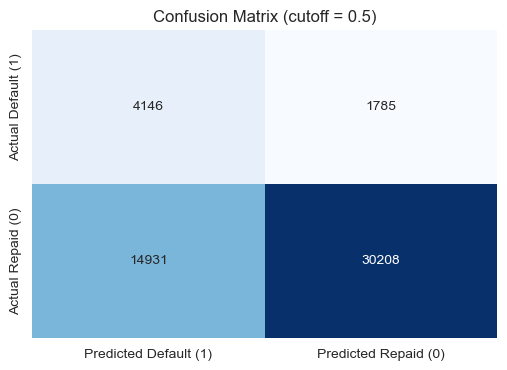

,Predicted Default (1),Predicted Repaid (0)
Actual Default (1),4146,1785
Actual Repaid (0),14931,30208


In [40]:
cm_df = pd.DataFrame(
    cm,
    index=[ "Actual Default (1)", "Actual Repaid (0)"],
    columns=["Predicted Default (1)", "Predicted Repaid (0)"],
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion Matrix (cutoff = 0.5)")
plt.show()

cm_df


### 8b. Accuracy, Precision, Recall, F1

- **Accuracy** = (TP + TN) / total. Misleading on imbalanced data — see how close it is to the base rate.
- **Precision** = TP / (TP + FP). Of the loans we flagged as defaults, what fraction actually defaulted?
- **Recall** (sensitivity) = TP / (TP + FN). Of the loans that actually defaulted, what fraction did we catch?
- **F1** = harmonic mean of precision and recall — a single combined number.


In [41]:
acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test)
f1   = f1_score(y_test, y_pred_test)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"\nNaive baseline (always predict 0) accuracy: {1 - y_test.mean():.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred_test, target_names=["Repaid", "Default"]))


Accuracy : 0.6727
Precision: 0.2173
Recall   : 0.6990
F1       : 0.3316

Naive baseline (always predict 0) accuracy: 0.8839

Full classification report:
              precision    recall  f1-score   support

      Repaid       0.94      0.67      0.78     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.67      0.73     51070



**Teaching point — the accuracy paradox.**
At a 0.5 cutoff, a logistic regression on this dataset is often only marginally better in *accuracy* than the naive "predict no default" baseline. But the naive baseline has **recall = 0** for the default class — it catches no defaulters at all. That is why we look at precision and recall separately, not just accuracy.


### 8c. ROC curve and AUC

The **ROC curve** plots the True Positive Rate (recall) against the False Positive Rate as we sweep the classification threshold from 1 down to 0. The **AUC** (area under the curve) summarises this in one number:

- AUC = 0.5 → the model is no better than random.
- AUC = 1.0 → perfect ranking of defaulters above non-defaulters.

ROC-AUC is **threshold-independent** — it tells you how well the model *ranks* applicants by risk, not how well any specific cutoff classifies them.


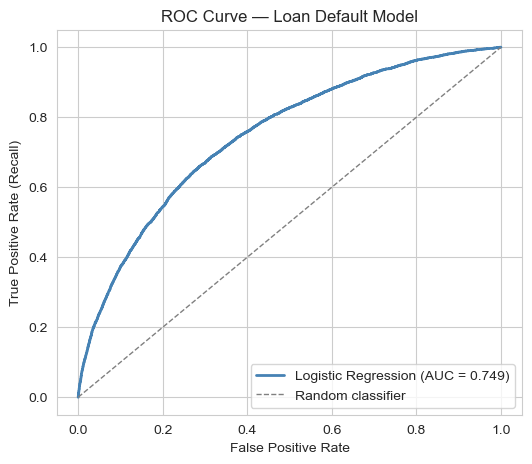

ROC-AUC: 0.7486


In [42]:
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Loan Default Model")
plt.legend(loc="lower right")
plt.show()

print(f"ROC-AUC: {auc:.4f}")


**How to read it.**

- The **dashed grey line** is the precision a random classifier would achieve — it equals the base rate (~0.116). Any useful model must sit above it.
- Moving **right** along the curve → catching more defaulters (higher recall) at the cost of more false alarms (lower precision).
- Moving **left** → being very picky about whom we flag — high precision, but we miss many defaulters.

The "right" point on this curve depends on the **business cost** of the two error types.


---

## 9. Choosing a threshold from a business cost view

The default 0.5 cutoff is a **statistical convention, not a business decision**.
Suppose:

- A **False Negative** (approving a loan that defaults) costs the bank, on average, the lost principal — say **₹100,000**.
- A **False Positive** (rejecting a loan that would have repaid) costs the bank the foregone interest — say **₹10,000**.

With those (illustrative) numbers, a missed default is 10× as expensive as a wrongly-rejected good borrower. We sweep thresholds and pick the one that minimises **total expected cost** on the test set.


In [43]:
COST_FN = 10   # cost of missing a default
COST_FP =  1   # cost of rejecting a good borrower

thresholds = np.linspace(0.05, 0.95, 91)
records = []

for t in thresholds:
    pred = (y_proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fn * COST_FN + fp * COST_FP
    records.append({
        "threshold": t,
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "recall":    tp / (tp + fn) if (tp + fn) else 0.0,
        "FP": fp, "FN": fn,
        "total_cost": cost,
    })

cost_df = pd.DataFrame(records)
best_idx = cost_df["total_cost"].idxmin()
best = cost_df.loc[best_idx]
print(f"Cost-optimal threshold: {best['threshold']:.2f}")
print(f"  Precision: {best['precision']:.4f}")
print(f"  Recall   : {best['recall']:.4f}")
print(f"  False Negatives: {int(best['FN'])}, False Positives: {int(best['FP'])}")
print(f"  Total cost on test set: ₹{best['total_cost']:,.0f}")


Cost-optimal threshold: 0.47
  Precision: 0.2052
  Recall   : 0.7439
  False Negatives: 1519, False Positives: 17088
  Total cost on test set: ₹32,278


/Users/manaranjanp/anaconda3/envs/mylabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


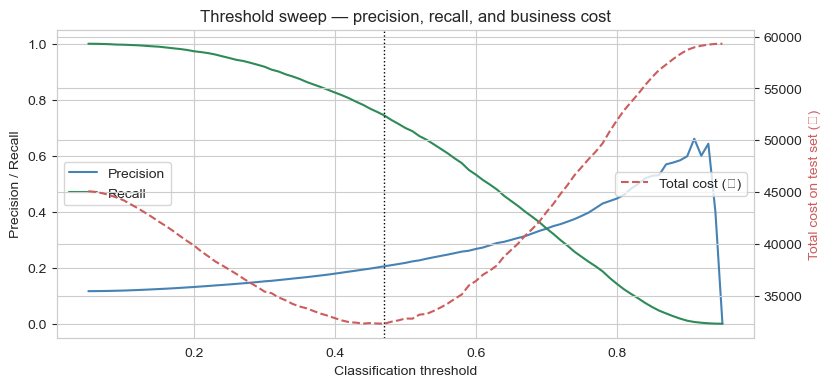

In [32]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(cost_df["threshold"], cost_df["precision"], color="steelblue", label="Precision")
ax1.plot(cost_df["threshold"], cost_df["recall"],    color="seagreen",  label="Recall")
ax1.set_xlabel("Classification threshold")
ax1.set_ylabel("Precision / Recall")
ax1.legend(loc="center left")

ax2 = ax1.twinx()
ax2.plot(cost_df["threshold"], cost_df["total_cost"], color="indianred", linestyle="--",
         label="Total cost (₹)")
ax2.axvline(best["threshold"], color="black", linestyle=":", linewidth=1)
ax2.set_ylabel("Total cost on test set (₹)", color="indianred")
ax2.legend(loc="center right")

plt.title("Threshold sweep — precision, recall, and business cost")
plt.show()


**Teaching point.** The cost-optimal threshold is almost always **lower than 0.5** for credit-risk problems, because the cost of missing a defaulter is much larger than the cost of rejecting a good borrower. The right number depends entirely on the bank's loss assumptions — change `COST_FN` and `COST_FP` and the chosen threshold moves.


---

## 10. Checking for overfitting

Two simple diagnostics:

1. **Compare training vs test performance.** A large gap (train much better than test) is a warning sign.
2. **Cross-validate** on the training set. If the AUC varies wildly across folds, the model is unstable and likely fitting noise.


In [44]:
# 1. Train vs Test
y_proba_train = model.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_proba_train)
auc_test  = roc_auc_score(y_test,  y_proba_test)

print(f"Train AUC: {auc_train:.4f}")
print(f"Test  AUC: {auc_test:.4f}")
print(f"Gap      : {auc_train - auc_test:+.4f}")


Train AUC: 0.7417
Test  AUC: 0.7486
Gap      : -0.0068


In [45]:
# 2. 5-fold stratified cross-validation on the TRAINING set only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print("CV ROC-AUC per fold:", np.round(cv_scores, 4))
print(f"CV ROC-AUC mean ± std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV ROC-AUC per fold: [0.7379 0.745  0.7361 0.7449 0.7438]
CV ROC-AUC mean ± std: 0.7415 ± 0.0038


**What good looks like.**

- Train AUC and Test AUC should be **close** to each other.
- The 5 fold scores should be **tight** (small standard deviation).

Logistic regression with default L2 regularisation is a *low-variance* model — it rarely overfits on a dataset this size. If we replaced it with a deep, unregularised tree-based model, we would expect to see a much larger gap and would have to push back with regularisation, fewer features, or more data.


---

## 11. Summary

| Topic | What we did |
|---|---|
| Problem framing | Binary classification of loan default on ~255k loans, ~11.6% positive class |
| Bias awareness | Discussed survivorship, look-ahead, and overfitting — and where each could enter this pipeline |
| Modelling | Logistic regression inside a `Pipeline` (scaling + one-hot + classifier) |
| Interpretability | Refit with `statsmodels.Logit` to inspect coefficients, p-values, and confidence intervals |
| Evaluation | Confusion matrix, accuracy / precision / recall / F1, ROC-AUC, **Precision-Recall curve + AP** |
| Threshold choice | Swept thresholds against an explicit **business cost** (FN ≫ FP) instead of using 0.5 |
| Overfitting checks | Compared train vs test AUC, ran 5-fold stratified CV, swept regularisation strength `C` |

**Things to try next.**

- Re-run with `class_weight="balanced"` in `LogisticRegression` and compare PR curves.
- Replace the classifier with a `RandomForestClassifier` or `GradientBoostingClassifier` — keep the preprocessing the same — and see how the train/test gap and AUC change.
- Plug your own `COST_FN` / `COST_FP` numbers into Section 9 and see how the optimal threshold moves.
